# V4-4-0 Portfolio

อัปเดตจาก `V3-4_portfolio` ให้ตรงกับ pipeline ใหม่ (`v4-3-0_inferencing`):
- **Data source**: รับ arrays จาก inferencing loop โดยตรง (`all_prices_gen`, `all_prices_real`, `all_log_ret_gen`, `all_log_ret_real`, `all_dates`) แทน `SimulationDataset` / `.npz`
- **Tensor dims**: shape ใหม่ `(N, W, A, C)` แทน `(N, A, W, D, C)` — A และ W สลับกัน, ไม่มี D
- **No GBM**: ไม่มี `simulate_mc_gbm` เป็น benchmark อีกแล้ว — มีแค่ `"model"` strategy เดียว
- **Imports**: ใช้ `load_data` / `build_datasets` (utils/io.py) แทน `load_variant`

# 1. Import & Config

In [1]:
import sys, os, json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import quantstats as qs
from pathlib import Path

from config import InferenceConfig, DDPMTransformerConfig, FMConfig
from utils import setup_logging, setup_random_seed, load_data, build_datasets
from utils.paths import PROCESSED_DIR, EXPERIMENTS_DIR
from entities import Portfolio

logger = setup_logging()
logger.info("✓ Imports OK")

2026-07-25 14:26:03,652 - utils.setup - INFO - Logger is set up.
2026-07-25 14:26:03,654 - utils.setup - INFO - ✓ Imports OK


## 1.1 Config

In [2]:
# 1. Import & Config
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import InferenceConfig
from utils import setup_logging, setup_random_seed

logger = setup_logging()
logger.info("✓ Imports OK")

# ── 1.1 Config ────────────────────────────────────────────────────────
cfg = InferenceConfig(
    name             = "portfolio_config",
    group            = "set_index",
    subgroup         = "set_idx50",
    experiment_name  = "v1_trial01_w20a33_ddpm_warmup-cosine_optuna",
    checkpoint_file  = "best_model.pt",
    num_simulations  = 1000,
    random_seed      = 72,
)
cfg = cfg.apply_experiment_config()

SPLIT = "test" # เปลี่ยนเป็น 'test' ได้ตามที่เซฟมา
sim_dir = cfg.experiment_dir / "simulations" / f"{SPLIT}_all_n{cfg.num_simulations}"

setup_random_seed(cfg.random_seed)

print("=" * 60)
print("  V4-4-0 PORTFOLIO")
print("=" * 60)
print(f"  Experiment      : {cfg.experiment_name}")
print(f"  Simulation dir  : {sim_dir}")
print("=" * 60)

2026-07-25 14:26:03,672 - utils.setup - INFO - Logger is set up.
2026-07-25 14:26:03,674 - utils.setup - INFO - ✓ Imports OK
[InferenceConfig] model_params loaded from best_params.json
  V4-4-0 PORTFOLIO
  Experiment      : v1_trial01_w20a33_ddpm_warmup-cosine_optuna
  Simulation dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/set_index/set_idx50/v1_trial01_w20a33_ddpm_warmup-cosine_optuna/simulations/test_all_n1000


# 2. Load Simulation Results

รับ arrays จาก `v4-3-0_inferencing` โดยตรง (ต้องรันก่อน หรือ pass ผ่าน shared state)

| variable | shape | description |
|---|---|---|
| `all_prices_gen` | list of `(N, W, A)` | generated close prices per window |
| `all_prices_real` | list of `(W, A)` | real close prices per window |
| `all_log_ret_gen` | list of `(N, W, A, C)` | generated log-returns (all channels) per window |
| `all_log_ret_real` | list of `(W, A, C)` | real log-returns (all channels) per window |
| `all_dates` | list of `datetime64` scalars | last date of each window |

## 2.1 ตรวจ Shape

In [3]:
# 2. Load Simulation Data (Direct Array Load)
npz_path = sim_dir / "result_all_windows.npz"

if not npz_path.exists():
    raise FileNotFoundError(f"Not found: {npz_path} (รัน inferencing หรือยัง?)")

data = np.load(npz_path, allow_pickle=True)

# โหลด arrays (T = จำนวน window, N = sims, W = window_size, A = assets, C = channels)
all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]

print(f"  ✓ Loaded 1 file from {SPLIT}_all_n{cfg.num_simulations}")
print(f"  all_prices_gen   : {all_prices_gen.shape}")
print(f"  all_prices_real  : {all_prices_real.shape}")
print(f"  all_log_ret_gen  : {all_log_ret_gen.shape}")
print(f"  all_log_ret_real : {all_log_ret_real.shape}")
print(f"  all_dates        : {all_dates.shape}")
print(f"  tickers          : {len(tickers)} assets")

  ✓ Loaded 1 file from test_all_n1000
  all_prices_gen   : (41, 1000, 20, 33)
  all_prices_real  : (41, 20, 33)
  all_log_ret_gen  : (41, 1000, 20, 33, 4)
  all_log_ret_real : (41, 20, 33, 4)
  all_dates        : (41,)
  tickers          : 33 assets


## 2.2 Prepare gt / mc returns

In [4]:
# 2.2 Prepare GT & MC Returns/Prices
# แปลง (T, N, W, A) -> (N, T*W, A) สำหรับ MC
# แปลง (T, W, A) -> (T*W, A) สำหรับ GT

CLOSE_IDX = 0  # เปลี่ยนให้ตรงกับ features_lr ของคุณ (0 = Close ปกติใน v4)

# ── 1. Ground Truth (GT) ──────────────────────────────────────────────
# log_ret_real : (T, W, A, C) -> เอาแค่ channel Close
gt_returns = all_log_ret_real[..., CLOSE_IDX] # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)        # (T*W, A)

# prices_real : (T, W, A) ไม่มี C แล้ว
gt_prices = all_prices_real.reshape(-1, A)    # (T*W, A)

# dates : (T, W) -> flatten เป็น 1D (T*W)
if all_dates.ndim == 2:
    gt_dates = all_dates.flatten()
else:
    gt_dates = all_dates

# ── 2. Monte Carlo (MC) ───────────────────────────────────────────────
# log_ret_gen : (T, N, W, A, C) -> เอาแค่ channel Close
mc_returns = all_log_ret_gen[..., CLOSE_IDX]  # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3) # ดึง N มาข้างหน้าสุด (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)     # ยุบรวมแกนเวลา -> (N, T*W, A)

# prices_gen : (T, N, W, A)
mc_prices = all_prices_gen.transpose(1, 0, 2, 3) # (N, T, W, A)
mc_prices = mc_prices.reshape(N, -1, A)          # (N, T*W, A)

print("── Shapes after preparation ───────────────────────")
print(f"  gt_returns  : {gt_returns.shape}   (n_periods, n_assets)")
print(f"  gt_prices   : {gt_prices.shape}   (n_periods, n_assets)")
print(f"  gt_dates    : {gt_dates.shape}")
print(f"  mc_returns  : {mc_returns.shape}  (n_sims, n_periods, n_assets)")
print(f"  mc_prices   : {mc_prices.shape}   (n_sims, n_periods, n_assets)")
print("───────────────────────────────────────────────────")

── Shapes after preparation ───────────────────────
  gt_returns  : (820, 33)   (n_periods, n_assets)
  gt_prices   : (820, 33)   (n_periods, n_assets)
  gt_dates    : (41,)
  mc_returns  : (1000, 820, 33)  (n_sims, n_periods, n_assets)
  mc_prices   : (1000, 820, 33)   (n_sims, n_periods, n_assets)
───────────────────────────────────────────────────


## 2.3 Sanity Check

In [5]:
# print(f"gt_returns shape : {gt_returns.shape}")
# print(f"mc_returns shape : {mc_returns.shape}")
# print()

# # 1. variance per asset ใน gt
# gt_var = np.var(gt_returns, axis=0)
# print("gt_returns variance per asset:")
# for i, (sym, v) in enumerate(zip(SYMBOLS, gt_var)):
#     flag = " ← ⚠️ near-zero" if v < 1e-8 else ""
#     print(f"  [{i:02d}] {sym:<6} var={v:.2e}{flag}")

# print()

# # 2. mc paths variance
# mc_var    = np.var(mc_returns, axis=1)   # (N, A)
# zero_paths = np.where(mc_var < 1e-8)
# if len(zero_paths[0]) > 0:
#     print(f"⚠️ mc_returns near-zero variance at (path, asset): {list(zip(*zero_paths))}")
# else:
#     print("✓ mc_returns variance OK")

# print()

# # 3. NaN / Inf
# print(f"gt NaN: {np.isnan(gt_returns).sum()}, Inf: {np.isinf(gt_returns).sum()}")
# print(f"mc NaN: {np.isnan(mc_returns).sum()}, Inf: {np.isinf(mc_returns).sum()}")

## 2.4 Build Date Index

In [6]:
CLOSE_IDX = 0  # channel สำหรับราคา Close

# 1. Ground Truth (GT): จับ T windows มาเรียงต่อกันให้เป็น n_periods ยาวๆ (T*W)
gt_returns = all_log_ret_real[..., CLOSE_IDX] # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)        # กลายเป็น (T*W, A) แบบเส้นเดียว

gt_prices = all_prices_real.reshape(-1, A)    # กลายเป็น (T*W, A) แบบเส้นเดียว

# จัดการ Date Index: เนื่องจากไม่มีการ Overlap เราสามารถสร้างตารางเวลาเรียงต่อกันได้เลย
all_dates_flat = []
for i in range(T):
    # รองรับเผื่อเป็น scalar 1D หรือ 2D
    date_val = all_dates[i] if np.isscalar(all_dates[i]) else all_dates[i, -1]
    dates_w = pd.bdate_range(end=pd.Timestamp(date_val), periods=W)
    all_dates_flat.append(dates_w)

datetime_index = pd.DatetimeIndex(np.concatenate(all_dates_flat))

# 2. Monte Carlo (MC): ยุบรวมแกน T กับ W เข้าด้วยกัน
mc_returns = all_log_ret_gen[..., CLOSE_IDX]  # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3) # ดึง N ออกมาหน้าสุด (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)     # กลายเป็น (N, T*W, A) แบบเส้นเดียว

print("── Target Shapes for Portfolio ────────────────────")
print(f"  gt_returns : {gt_returns.shape}   (n_periods = {T*W}, n_assets = {A})")
print(f"  gt_prices  : {gt_prices.shape}   (n_periods = {T*W}, n_assets = {A})")
print(f"  datetime   : {len(datetime_index)} days")
print(f"  mc_returns : {mc_returns.shape}  (n_paths = {N}, n_periods = {T*W}, n_assets = {A})")
print("───────────────────────────────────────────────────")

── Target Shapes for Portfolio ────────────────────
  gt_returns : (820, 33)   (n_periods = 820, n_assets = 33)
  gt_prices  : (820, 33)   (n_periods = 820, n_assets = 33)
  datetime   : 820 days
  mc_returns : (1000, 820, 33)  (n_paths = 1000, n_periods = 820, n_assets = 33)
───────────────────────────────────────────────────


# 3. Portfolio Optimization Loop

In [7]:
CLOSE_FEATURE    = "Close"      # ชื่อ channel ที่ใช้ reconstruct ราคา

loaded   = load_data(str(cfg.processed_dir))
datasets = build_datasets(loaded)

tickers       = loaded["tickers"]
features_lr   = loaded["features_lr"]
features_cond = loaded["features_cond"]
scalers_x     = loaded["scalers_x"]
scalers_cond  = loaded["scalers_cond"]

CLOSE_IDX = features_lr.index(CLOSE_FEATURE)

print(f"tickers      : {tickers}")
print(f"features_lr  : {features_lr}")
print(f"close idx    : {CLOSE_IDX}")
for s in ("train", "val", "test"):
    print(f"  {s:<6} n_windows={len(datasets[s])}")

tickers      : ['ADVANC.BK', 'AOT.BK', 'BANPU.BK', 'BBL.BK', 'BDMS.BK', 'BEM.BK', 'BH.BK', 'BJC.BK', 'BTS.BK', 'CENTEL.BK', 'CPALL.BK', 'CPF.BK', 'CPN.BK', 'DELTA.BK', 'EGCO.BK', 'GLOBAL.BK', 'HMPRO.BK', 'IRPC.BK', 'KBANK.BK', 'KKP.BK', 'KTB.BK', 'KTC.BK', 'LH.BK', 'MINT.BK', 'PTT.BK', 'PTTEP.BK', 'RATCH.BK', 'SCC.BK', 'TCAP.BK', 'TISCO.BK', 'TOP.BK', 'TRUE.BK', 'TU.BK']
features_lr  : ['Close', 'High', 'Low', 'Open']
close idx    : 0
  train  n_windows=1912
  val    n_windows=229
  test   n_windows=815


In [8]:
import random

SIM_MODE = "strided"    # ← เปลี่ยนตรงนี้: "single" | "full" | "strided"

# ── config เฉพาะของแต่ละ mode ─────────────────────────────────
SINGLE_WINDOW_IDX  = None   # None → สุ่ม, หรือใส่ int ตรง ๆ เช่น 42
STRIDED_WINDOW_W   = W      # stride = W (non-overlapping), หรือตัวเลขอื่น

# ── validate ──────────────────────────────────────────────────
assert SIM_MODE in ("single", "full", "strided"), \
    f"SIM_MODE ต้องเป็น 'single' | 'full' | 'strided', ได้: {SIM_MODE!r}"

ds        = datasets[SPLIT]
n_windows = len(ds)
dates     = loaded["splits"][SPLIT]["dates"]

if SIM_MODE == "single":
    if SINGLE_WINDOW_IDX is None:
        _w = random.randint(0, n_windows - 1)
    else:
        assert 0 <= SINGLE_WINDOW_IDX < n_windows, \
            f"SINGLE_WINDOW_IDX={SINGLE_WINDOW_IDX} out of range [0, {n_windows-1}]"
        _w = SINGLE_WINDOW_IDX
    window_idxs = [_w]
    print(f"  MODE : single window")
    print(f"  idx  : {_w}  (date={dates[_w]})")

elif SIM_MODE == "full":
    window_idxs = list(range(n_windows))
    print(f"  MODE : full split ({SPLIT})")
    print(f"  windows : {n_windows}")

elif SIM_MODE == "strided":
    stride      = max(1, STRIDED_WINDOW_W)
    window_idxs = list(range(0, n_windows, stride))
    print(f"  MODE : strided (stride={stride}, W={W})")
    print(f"  windows total   : {n_windows}")
    print(f"  windows to run  : {len(window_idxs)}")

print(f"  split           : {SPLIT}")
print(f"  num_simulations : {cfg.num_simulations}")

  MODE : strided (stride=20, W=20)
  windows total   : 815
  windows to run  : 41
  split           : test
  num_simulations : 1000


In [9]:
import torch
from utils import simulate_mc_gbm

print("🎲 Simulating GBM Benchmark...")

# แปลง gt_returns ที่แบนแล้ว (T*W, A) เป็น Tensor
gt_returns_tensor = torch.tensor(gt_returns, dtype=torch.float32)

# จำนวน Paths (ดึงจากขนาดของ mc_returns)
n_paths = mc_returns.shape[0]
# ความยาววันทั้งหมด
horizon_len = len(gt_returns)

# สร้าง GBM โดยใช้ mu, sigma จาก gt_returns_tensor
gbm_tensor = simulate_mc_gbm(
    log_returns=gt_returns_tensor,
    n_paths=n_paths,
    horizon=horizon_len
)

# แปลงกลับเป็น NumPy (ได้รูปทรง: [n_paths, horizon_len, n_assets])
gbm_returns = gbm_tensor.cpu().numpy()
print(f"  gbm_returns: {gbm_returns.shape}")
print("──────────────────────────────────────────────────────────────────")

🎲 Simulating GBM Benchmark...
  gbm_returns: (1000, 820, 33)
──────────────────────────────────────────────────────────────────


In [10]:
# 2. Load Simulation Data (จาก Inferencing)
npz_path = sim_dir / "result_all_windows.npz"

if not npz_path.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ {npz_path} กรุณารัน V4-3-0 Inferencing ก่อน")

data = np.load(npz_path, allow_pickle=True)

all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]

print(f"  ✓ Loaded 1 file from {SPLIT}_all_n{cfg.num_simulations}")
print(f"  Total Windows (T) = {T}, Simulations (N) = {N}, Window Size (W) = {W}")

  ✓ Loaded 1 file from test_all_n1000
  Total Windows (T) = 41, Simulations (N) = 1000, Window Size (W) = 20


In [11]:
# 3. Prepare All-Window Concatenated Data
CLOSE_IDX = 0

# 3.1 Ground Truth (GT): จับ T windows มาต่อกันเป็นเส้นเดียวยาวๆ
gt_returns = all_log_ret_real[..., CLOSE_IDX]   # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)          # (T*W, A)
gt_prices = all_prices_real.reshape(-1, A)      # (T*W, A)

# 3.2 จัดการ Datetime Index
all_dates_flat = []
for i in range(T):
    date_val = all_dates[i] if np.isscalar(all_dates[i]) else all_dates[i, -1]
    dates_w = pd.bdate_range(end=pd.Timestamp(date_val), periods=W)
    all_dates_flat.append(dates_w)

datetime_index = pd.DatetimeIndex(np.concatenate(all_dates_flat))

# 3.3 Monte Carlo (MC): ดึง N ออกมาหน้าสุด แล้วยุบเวลา (T*W)
mc_returns = all_log_ret_gen[..., CLOSE_IDX]     # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3)    # (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)        # (N, T*W, A)

print(f"  ✓ gt_returns shape : {gt_returns.shape}")
print(f"  ✓ mc_returns shape : {mc_returns.shape}")
print(f"  ✓ Date Range       : {datetime_index[0].date()} to {datetime_index[-1].date()}")

  ✓ gt_returns shape : (820, 33)
  ✓ mc_returns shape : (1000, 820, 33)
  ✓ Date Range       : 2021-12-31 to 2025-12-09


In [12]:
all_dates.shape

(41,)

In [13]:
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier
import vectorbt as vbt
import quantstats as qs
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. การเตรียมข้อมูลจาก Tensor ของคุณ
# ==========================================
# all_log_ret_gen shape: (T, N, W, A, C) -> (101, 100, 20, 88, 4)
# สมมติว่า Channel 0 (C=0) คือ Close log-return
close_log_ret_gen = all_log_ret_gen[:, :, :, :, 0]

# ดึงวันที่ rebalance (ใช้วันสุดท้ายของแต่ละ window)
# all_dates shape: (101, 20)
rebalance_dates = pd.to_datetime(all_dates)

# ดึงราคาจริง ณ วันที่ rebalance เพื่อใช้จำลองพอร์ต
# all_prices_real shape: (101, 20, 88)
real_prices = all_prices_real[:, -1, :]
df_prices = pd.DataFrame(real_prices, index=rebalance_dates, columns=tickers)

# ตั้งค่าพารามิเตอร์ตามวิทยานิพนธ์
RF_RATE = 0.02         # Risk-free rate 2% ต่อปี[cite: 1]
TRADING_FEE = 0.0025   # Transaction cost 0.25%[cite: 1]
TRADING_DAYS = 252     # จำนวนวันเทรดใน 1 ปีสำหรับการทำ Annualize

weights_list = []

print("🚀 เริ่มกระบวนการ Layer 2: MPT Optimization (Cross-path Averaging)...")

# ==========================================
# 2. คำนวณ μ และ Σ และทำ Portfolio Optimization
# ==========================================
for t in range(T):
    mu_paths = []
    cov_paths = []

    # วนลูปผ่านทุกๆ Path (N = 100) เพื่อสร้าง Ensemble
    for n in range(N):
        path_log_returns = close_log_ret_gen[t, n, :, :] # Shape: (W, A)
        path_simple_returns = np.exp(path_log_returns) - 1

        mu_m = np.mean(path_simple_returns, axis=0) * TRADING_DAYS
        cov_m = np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS

        mu_paths.append(mu_m)
        cov_paths.append(cov_m)

    # Statistical Aggregation
    mu_ensemble = np.mean(mu_paths, axis=0)
    cov_ensemble = np.mean(cov_paths, axis=0)

    mu_series = pd.Series(mu_ensemble, index=tickers)
    cov_df = pd.DataFrame(cov_ensemble, index=tickers, columns=tickers)

    # Modern Portfolio Theory (MPT) Optimizer
    ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))

    try:
        # เทคนิคที่ 1: Dynamic Risk-Free Rate
        # เช็คว่ามีหุ้นตัวไหนชนะ RF_RATE ของเราไหม
        current_rf = RF_RATE
        max_mu = mu_series.max()

        if max_mu <= current_rf:
            # ถ้าหุ้นทุกตัวผลตอบแทนแย่กว่า 2% ให้แอบปรับ Risk-free ลงชั่วคราว
            # ให้อยู่ต่ำกว่าตัวที่ผลตอบแทนดีที่สุดเล็กน้อย เพื่อให้สมการทำงานได้
            current_rf = max_mu - 0.001

        # เทคนิคที่ 2: L2 Regularization (ป้องกัน Covariance Matrix พังจากข้อมูล Gen AI)
        # นำเข้า objective_functions จาก pypfopt หากยังไม่ได้นำเข้าที่ต้นไฟล์
        from pypfopt import objective_functions
        ef.add_objective(objective_functions.L2_reg, gamma=0.05) # gamma 0.05 ช่วยเกลี่ยน้ำหนักไม่ให้กระจุกตัวเกินไป

        # พยายามหาจุด Maximize Sharpe Ratio ด้วย RF ที่อาจถูกปรับแก้แล้ว
        raw_weights = ef.max_sharpe(risk_free_rate=current_rf)
        print("used max_sharpe optimization for window", t)

    except ValueError as e:
        # Fallback: หากยังพังอีก (เช่น หาคำตอบทางคณิตศาสตร์ไม่ได้จริงๆ) ค่อยใช้ Min Volatility
        ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1)) # Re-initialize
        raw_weights = ef.min_volatility()
        print("used min_volatility fallback due to error:", e)
    cleaned_weights = ef.clean_weights()

    # จัดเรียง Weight ให้ตรงกับลำดับของ Tickers
    w_array = np.array([cleaned_weights[ticker] for ticker in tickers])

    weights_list.append(w_array)

# สร้าง DataFrame ของ Weights
df_weights = pd.DataFrame(weights_list, index=rebalance_dates, columns=tickers)
print("  ✓ Optimization เสร็จสิ้น")

# ==========================================
# 3. จำลองการเทรดและ Backtesting ด้วย VectorBT
# ==========================================
print("📈 กำลังจำลองพอร์ตการลงทุน...")

portfolio = vbt.Portfolio.from_orders(
    close=df_prices,
    size=df_weights,            # ใช้ DataFrame น้ำหนักที่เราคำนวณมา
    size_type='targetpercent',  # บอก VectorBT ว่าตัวเลขนี้คือ 'น้ำหนักเป้าหมาย (Weight %)'
    cash_sharing=True,          # สำคัญมาก! อนุญาตให้แชร์เงินสดในพอร์ต เพื่อสลับตัวเล่นได้
    call_seq='auto',            # ให้ระบบจัดการลำดับอัตโนมัติ (ขายสินทรัพย์เดิมก่อนซื้อสินทรัพย์ใหม่)
    fees=TRADING_FEE,           # ค่าธรรมเนียม 0.25%
    freq='1D'                   # ความถี่ของการเก็บข้อมูล
)

# ==========================================
# 4. ประเมินผลลัพธ์ด้วย QuantStats
# ==========================================
print("📊 สรุปผลลัพธ์ด้วย QuantStats...")
portfolio_returns = portfolio.returns()

# พิมพ์ Metrics สำคัญออกมาทาง Console
qs.reports.metrics(portfolio_returns, rf=RF_RATE)

# สร้างไฟล์ HTML Report ไว้แนบภาคผนวกวิทยานิพนธ์
qs.reports.html(portfolio_returns, rf=RF_RATE, title="Generative AI Portfolio Performance", output="thesis_portfolio_report.html")
print("🎉 สำเร็จ! ตรวจสอบผลลัพธ์ได้ที่ 'thesis_portfolio_report.html'")

🚀 เริ่มกระบวนการ Layer 2: MPT Optimization (Cross-path Averaging)...
used max_sharpe optimization for window 0
used max_sharpe optimization for window 1
used max_sharpe optimization for window 2
used max_sharpe optimization for window 3
used max_sharpe optimization for window 4
used max_sharpe optimization for window 5
used max_sharpe optimization for window 6
used max_sharpe optimization for window 7
used max_sharpe optimization for window 8
used max_sharpe optimization for window 9
used max_sharpe optimization for window 10
used max_sharpe optimization for window 11
used max_sharpe optimization for window 12
used min_volatility fallback due to error: risk_free_rate should be numeric
used max_sharpe optimization for window 14
used max_sharpe optimization for window 15
used max_sharpe optimization for window 16
used max_sharpe optimization for window 17
used max_sharpe optimization for window 18
used min_volatility fallback due to error: risk_free_rate should be numeric
used max_sharpe

In [14]:
df_weights

,ADVANC.BK,AOT.BK,BANPU.BK,BBL.BK,BDMS.BK,BEM.BK,BH.BK,BJC.BK,BTS.BK,CENTEL.BK,...,MINT.BK,PTT.BK,PTTEP.BK,RATCH.BK,SCC.BK,TCAP.BK,TISCO.BK,TOP.BK,TRUE.BK,TU.BK
2022-01-27,0.00823,0.10125,0.04518,0.01801,0.00588,0.00000,0.00000,0.00000,0.00000,0.02940,...,0.04264,0.03653,0.03776,0.00000,0.04478,0.00883,0.00000,0.04715,0.09911,0.00000
2022-02-25,0.06552,0.04765,0.08967,0.05828,0.00391,0.00000,0.01429,0.04905,0.01410,0.00000,...,0.00230,0.05586,0.00000,0.00000,0.03904,0.03481,0.04182,0.03648,0.04023,0.00000
2022-03-25,0.00000,0.91254,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2022-04-28,0.00000,0.13019,0.00000,0.00000,0.08131,0.09379,0.00000,0.01776,0.00000,0.07529,...,0.00000,0.13215,0.00000,0.00000,0.00000,0.00000,0.07871,0.00000,0.00000,0.00000
2022-05-31,0.00000,0.17046,0.00000,0.09875,0.02738,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2022-06-29,0.04264,0.05705,0.03967,0.02667,0.03117,0.00000,0.02533,0.02759,0.00800,0.03376,...,0.04480,0.05460,0.06705,0.00000,0.04366,0.00936,0.00251,0.05711,0.05663,0.00000
2022-08-01,0.03225,0.07186,0.04062,0.01462,0.00572,0.03105,0.03740,0.02403,0.00000,0.03444,...,0.02958,0.06162,0.07299,0.00000,0.04185,0.02486,0.00000,0.01433,0.02928,0.01798
2022-08-30,0.08499,0.07953,0.00000,0.00000,0.00931,0.00000,0.10320,0.00000,0.00000,0.00000,...,0.00000,0.12616,0.00000,0.00000,0.00000,0.00000,0.00000,0.18075,0.00000,0.00000
2022-09-27,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2022-10-28,0.03274,0.05812,0.00000,0.00000,0.07893,0.02815,0.03618,0.03016,0.04142,0.04550,...,0.07317,0.00000,0.00000,0.01195,0.00000,0.00000,0.03735,0.00000,0.06962,0.00229


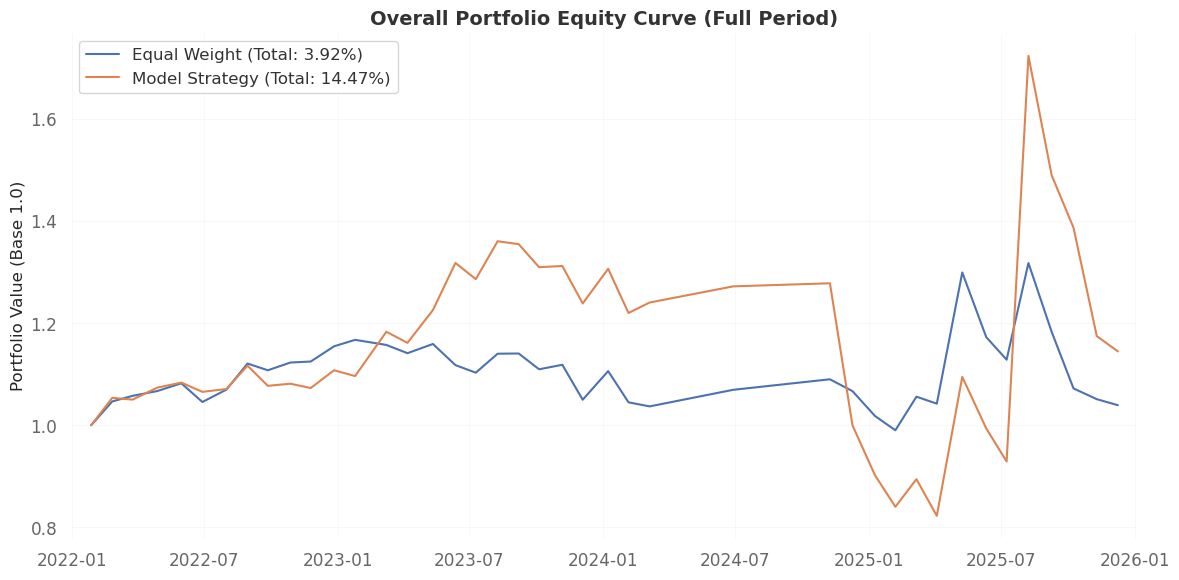

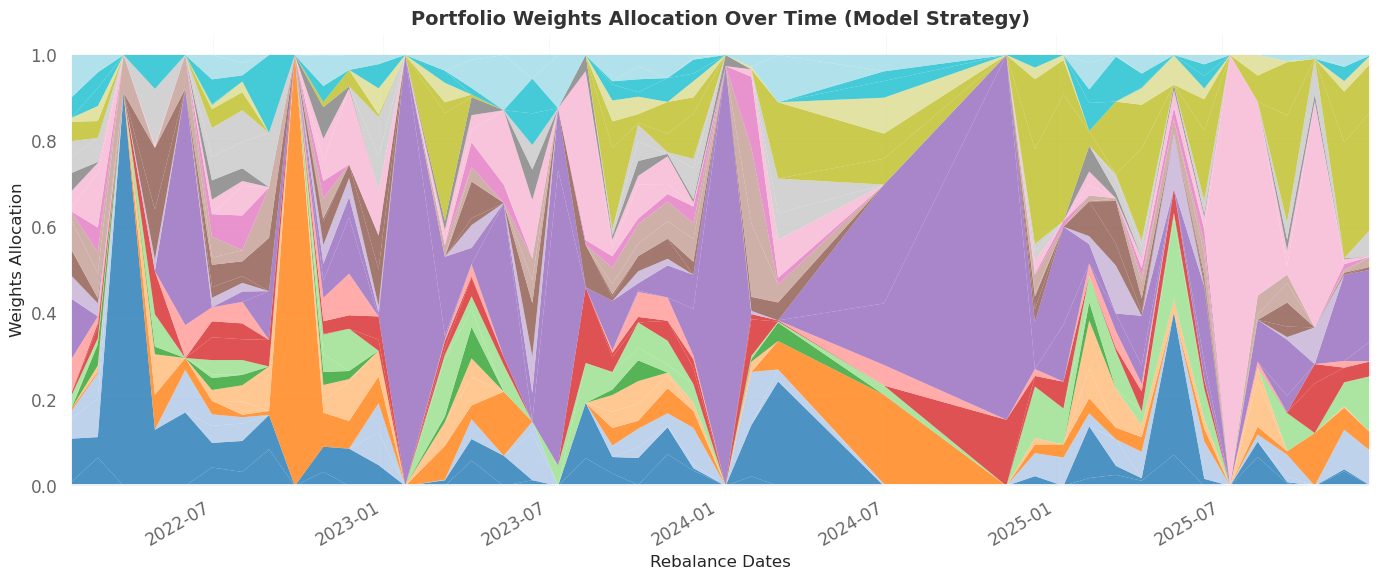

In [15]:
df_weights_ew = pd.DataFrame(1/A, index=rebalance_dates, columns=tickers)

# จำลองพอร์ต Equal Weight ด้วย VectorBT
portfolio_ew = vbt.Portfolio.from_orders(
    close=df_prices,
    size=df_weights_ew,
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

# ==========================================
# 2. พล็อตกราฟ Overall Portfolio Equity Curve
# ==========================================
# ดึงมูลค่าพอร์ตและปรับฐานให้เริ่มต้นที่ 1.0
eq_model = portfolio.value() / portfolio.value().iloc[0]
eq_ew = portfolio_ew.value() / portfolio_ew.value().iloc[0]

# คำนวณผลตอบแทนรวม (Total Return) เป็นเปอร์เซ็นต์
tot_ret_model = (eq_model.iloc[-1] - 1) * 100
tot_ret_ew = (eq_ew.iloc[-1] - 1) * 100

plt.figure(figsize=(12, 6))

# พล็อตเส้นกราฟ สีและสไตล์ให้คล้ายกับไฟล์ "image_e53405.png"
plt.plot(eq_ew.index, eq_ew, label=f'Equal Weight (Total: {tot_ret_ew:.2f}%)', color='#4c72b0', linewidth=1.5)
plt.plot(eq_model.index, eq_model, label=f'Model Strategy (Total: {tot_ret_model:.2f}%)', color='#dd8452', linewidth=1.5)

plt.title('Overall Portfolio Equity Curve (Full Period)', fontweight='bold', fontsize=14)
plt.ylabel('Portfolio Value (Base 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.2, color='lightgray')
plt.margins(x=0.02)
plt.tight_layout()
plt.show()

# ==========================================
# 3. พล็อตกราฟ Portfolio Weights Allocation
# ==========================================
plt.figure(figsize=(14, 6))

# ใช้ Area Plot เพื่อดูการเปลี่ยนแปลงของน้ำหนัก (กรณีมี 88 สินทรัพย์ สีอาจจะซ้ำกันบ้าง แต่จะเห็นเทรนด์การกระจุกตัว)
df_weights.plot.area(ax=plt.gca(), colormap='tab20', alpha=0.8, legend=False, linewidth=0)

plt.title('Portfolio Weights Allocation Over Time (Model Strategy)', fontweight='bold', fontsize=14)
plt.ylabel('Weights Allocation', fontsize=12)
plt.xlabel('Rebalance Dates', fontsize=12)
plt.margins(x=0, y=0)
plt.grid(True, alpha=0.2, color='lightgray')
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from scipy.optimize import minimize
# =====================================================================
# 1. GBM Benchmark (Monte Carlo Simulation)
# =====================================================================
def simulate_gbm_benchmark(S0, mu, sigma, T, dt=1):
    """
    Simulate future price paths using Geometric Brownian Motion (GBM).
    อ้างอิงจากสมการ (4) ในเล่ม: St+dt = St * exp((mu - (sigma^2)/2)*dt + sigma*sqrt(dt)*Z)
    """
    N = int(T / dt)
    prices = np.zeros(N)
    prices[0] = S0

    for t in range(1, N):
        Z = np.random.standard_normal() # Z ~ N(0, 1)[cite: 1]
        # คำนวณ GBM Step[cite: 1]
        drift = (mu - (sigma**2) / 2) * dt
        diffusion = sigma * np.sqrt(dt) * Z
        prices[t] = prices[t-1] * np.exp(drift + diffusion)

    return prices

# =====================================================================
# 2. Modern Portfolio Theory (Mean-Variance Optimization)
# =====================================================================
def mean_variance_optimization(mu_vec, cov_matrix, target_return):
    """
    หา Optimal weights ตามกรอบของ MPT[cite: 1]
    Objective: Minimize Risk (w^T * Sigma * w)[cite: 1]
    """
    num_assets = len(mu_vec)

    # ฟังก์ชันเป้าหมาย: ความเสี่ยงรวมของพอร์ตโฟลิโอ (Portfolio Variance)[cite: 1]
    def portfolio_variance(w):
        return w.T @ cov_matrix @ w

    # กำหนด Constraints ตามสมการที่ (2) ในเปเปอร์[cite: 1]
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},           # 1^T w = 1 (Full budget allocation)[cite: 1]
        {'type': 'ineq', 'fun': lambda w: w.T @ mu_vec - target_return}  # w^T mu >= mu_target (Minimum return threshold)[cite: 1]
    )

    # ขอบเขตของ Weights: w >= 0 (Prohibits short-selling)[cite: 1]
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))

    # ค่าเริ่มต้น (Initial guess) สมมติให้เป็น Equal Weight ก่อนเริ่ม Optimize
    init_guess = np.ones(num_assets) / num_assets

    # ทำการ Optimize หาค่า w ที่ดีที่สุด
    result = minimize(portfolio_variance,
                      init_guess,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints)

    if result.success:
        return result.x
    else:
        raise ValueError("Optimization failed to find a valid portfolio weight.")

In [ ]:
# =====================================================================
# 5. กำหนดและเรียกใช้ GBM Benchmark + Classic MPT
# =====================================================================
print("🚀 เริ่มกระบวนการ Baseline: GBM + Scipy MPT (Monte Carlo Simulation)...")

# จำนวนสินทรัพย์ (A) อิงจาก tickers ของคุณ
A = len(tickers)
weights_list_baseline = []

# สมมติฐาน: เราดึงจำนวนวันต่อ Window จาก shape ของ Gen Tensor
W = close_log_ret_gen.shape[2]
dt_step = 1 / TRADING_DAYS
T_sim_years = W / TRADING_DAYS # สัดส่วนของเวลาใน 1 Window เมื่อเทียบกับปี

for t in range(T):
    # --- ขั้นตอนที่ 5.1: หา Historical mu และ sigma ของแต่ละหุ้น ---
    # เพื่อให้แฟร์กับโมเดล เราจะใช้ Path แรกของข้อมูล Gen (หรือจะใช้ข้อมูลราคาจริงในอดีต Window ก่อนหน้าก็ได้)
    # เพื่อเป็นตัวแทนของข้อมูล Historical ในการสร้างพารามิเตอร์สำหรับ GBM
    hist_log_ret = close_log_ret_gen[t, 0, :, :] # Shape: (W, A)
    hist_simple_ret = np.exp(hist_log_ret) - 1

    mu_hist = np.mean(hist_simple_ret, axis=0) * TRADING_DAYS
    sigma_hist = np.std(hist_simple_ret, axis=0) * np.sqrt(TRADING_DAYS)

    # --- ขั้นตอนที่ 5.2: จำลองเส้นทางราคาด้วย GBM ---
    gbm_simulated_returns = []

    for i in range(A):
        asset_sim_paths = []
        S0 = 1.0 # Normalized ราคาเริ่มต้น

        # วนลูปสร้าง N paths แบบ Monte Carlo ด้วย GBM (อิงสมการที่ 4 ของคุณ)
        for _ in range(N):
            sim_prices = simulate_gbm_benchmark(S0, mu_hist[i], sigma_hist[i], T=T_sim_years, dt=dt_step)
            # คำนวณ Simple Return ของ Path นี้ (ราคาวันสุดท้าย - วันแรก / วันแรก)
            sim_ret = (sim_prices[-1] - sim_prices[0]) / sim_prices[0]
            asset_sim_paths.append(sim_ret)

        gbm_simulated_returns.append(asset_sim_paths)

    # แปลง Shape กลับเป็น (N paths, A assets)
    gbm_returns_matrix = np.array(gbm_simulated_returns).T

    # คำนวณ Expected Return (\mu) และ Covariance (\Sigma) จากเส้นทางที่ GBM จำลอง
    mu_vec_gbm = np.mean(gbm_returns_matrix, axis=0)
    cov_matrix_gbm = np.cov(gbm_returns_matrix, rowvar=False)

    # --- ขั้นตอนที่ 5.3: Optimize ด้วย MPT ปกติ ---
    # ตั้งเป้าหมายผลตอบแทน (Target Return) เป็นค่าเฉลี่ยของตลาด (ป้องกันเงื่อนไขตึงเกินไปจน Optimize พัง)
    target_ret = np.mean(mu_vec_gbm)

    try:
        # เรียกใช้ฟังก์ชัน Optimize ของคุณ (สมการที่ 2)
        w_opt = mean_variance_optimization(mu_vec_gbm, cov_matrix_gbm, target_return=target_ret)
    except ValueError:
        # Fallback หาก Optimizer หาจุดลงตัวไม่ได้ ให้เกลี่ยน้ำหนักเท่ากัน
        w_opt = np.ones(A) / A

    weights_list_baseline.append(w_opt)

# สร้าง DataFrame สำหรับ Baseline Weights
df_weights_baseline = pd.DataFrame(weights_list_baseline, index=rebalance_dates, columns=tickers)
print("  ✓ GBM + MPT Optimization เสร็จสิ้น")

# =====================================================================
# 6. จำลองการเทรด Baseline (GBM + MPT) ด้วย VectorBT
# =====================================================================
print("📈 กำลังจำลองพอร์ต GBM Baseline...")
portfolio_baseline = vbt.Portfolio.from_orders(
    close=df_prices,
    size=df_weights_baseline,
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

# =====================================================================
# 7. พล็อตกราฟเปรียบเทียบทั้ง 3 กลยุทธ์ (Model vs EW vs GBM Baseline)
# =====================================================================
# ดึงมูลค่าพอร์ตและปรับฐานให้เริ่มต้นที่ 1.0 (Base 1.0)
eq_model = portfolio.value() / portfolio.value().iloc[0]
eq_ew = portfolio_ew.value() / portfolio_ew.value().iloc[0]
eq_baseline = portfolio_baseline.value() / portfolio_baseline.value().iloc[0]

# คำนวณผลตอบแทนรวม (Total Return %)
tot_ret_model = (eq_model.iloc[-1] - 1) * 100
tot_ret_ew = (eq_ew.iloc[-1] - 1) * 100
tot_ret_baseline = (eq_baseline.iloc[-1] - 1) * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# เส้นที่ 1: Equal Weight
plt.plot(eq_ew.index, eq_ew, label=f'Equal Weight (Total: {tot_ret_ew:.2f}%)', color='#b6d1fa', linewidth=1.5, linestyle='--')
# เส้นที่ 2: GBM + MPT Baseline (จากฟังก์ชันของคุณ)
plt.plot(eq_baseline.index, eq_baseline, label=f'GBM + MPT (Total: {tot_ret_baseline:.2f}%)', color='#5eb072', linewidth=2.0)
# เส้นที่ 3: Model Strategy (AI Gen)
plt.plot(eq_model.index, eq_model, label=f'Model Strategy (AI) (Total: {tot_ret_model:.2f}%)', color='#f9cac2', linewidth=2.5)

plt.title('Overall Portfolio Equity Curve Comparison', fontweight='bold', fontsize=16)
plt.ylabel('Portfolio Value (Base 1.0)', fontsize=12)
plt.xlabel('Rebalance Dates', fontsize=12)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, color='gray')
plt.margins(x=0.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 8. (Optional) สร้าง Report ด้วย Quantstats สำหรับ Baseline
# =====================================================================
baseline_returns = portfolio_baseline.returns()
qs.reports.html(baseline_returns, rf=RF_RATE, title="GBM Baseline Portfolio Performance", output="thesis_baseline_report.html")
print("🎉 สำเร็จ! เปรียบเทียบเรียบร้อย สามารถตรวจสอบรายงาน Baseline ได้ที่ 'thesis_baseline_report.html'")

🚀 เริ่มกระบวนการ Baseline: GBM + Scipy MPT (Monte Carlo Simulation)...


KeyboardInterrupt: 

2026-07-25 03:02:19,711 - utils.setup - INFO - Logger is set up.
2026-07-25 03:02:19,712 - utils.setup - INFO - ✓ Imports OK


[InferenceConfig] model_params loaded from best_params.json
  V4-4-0 PORTFOLIO PIPELINE
  ✓ Loaded data from test_all_n1000
  ✓ Cleaned Dates: 820 -> 820 unique valid days

🚀 Running Portfolio Optimization...
2026-07-25 03:02:24,676 - entities.portfolio - INFO - evaluate: using equal-weight (mc_returns=None)


/home/narodom.y@FUSION.LAB/research/src/entities/portfolio.py:230: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/home/narodom.y@FUSION.LAB/research/src/entities/portfolio.py:230: FutureWarning:

Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`

/home/narodom.y@FUSION.LAB/research/src/entities/portfolio.py:230: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/home/narodom.y@FUSION.LAB/research/src/entities/portfolio.py:230: FutureWarning:

Series.__

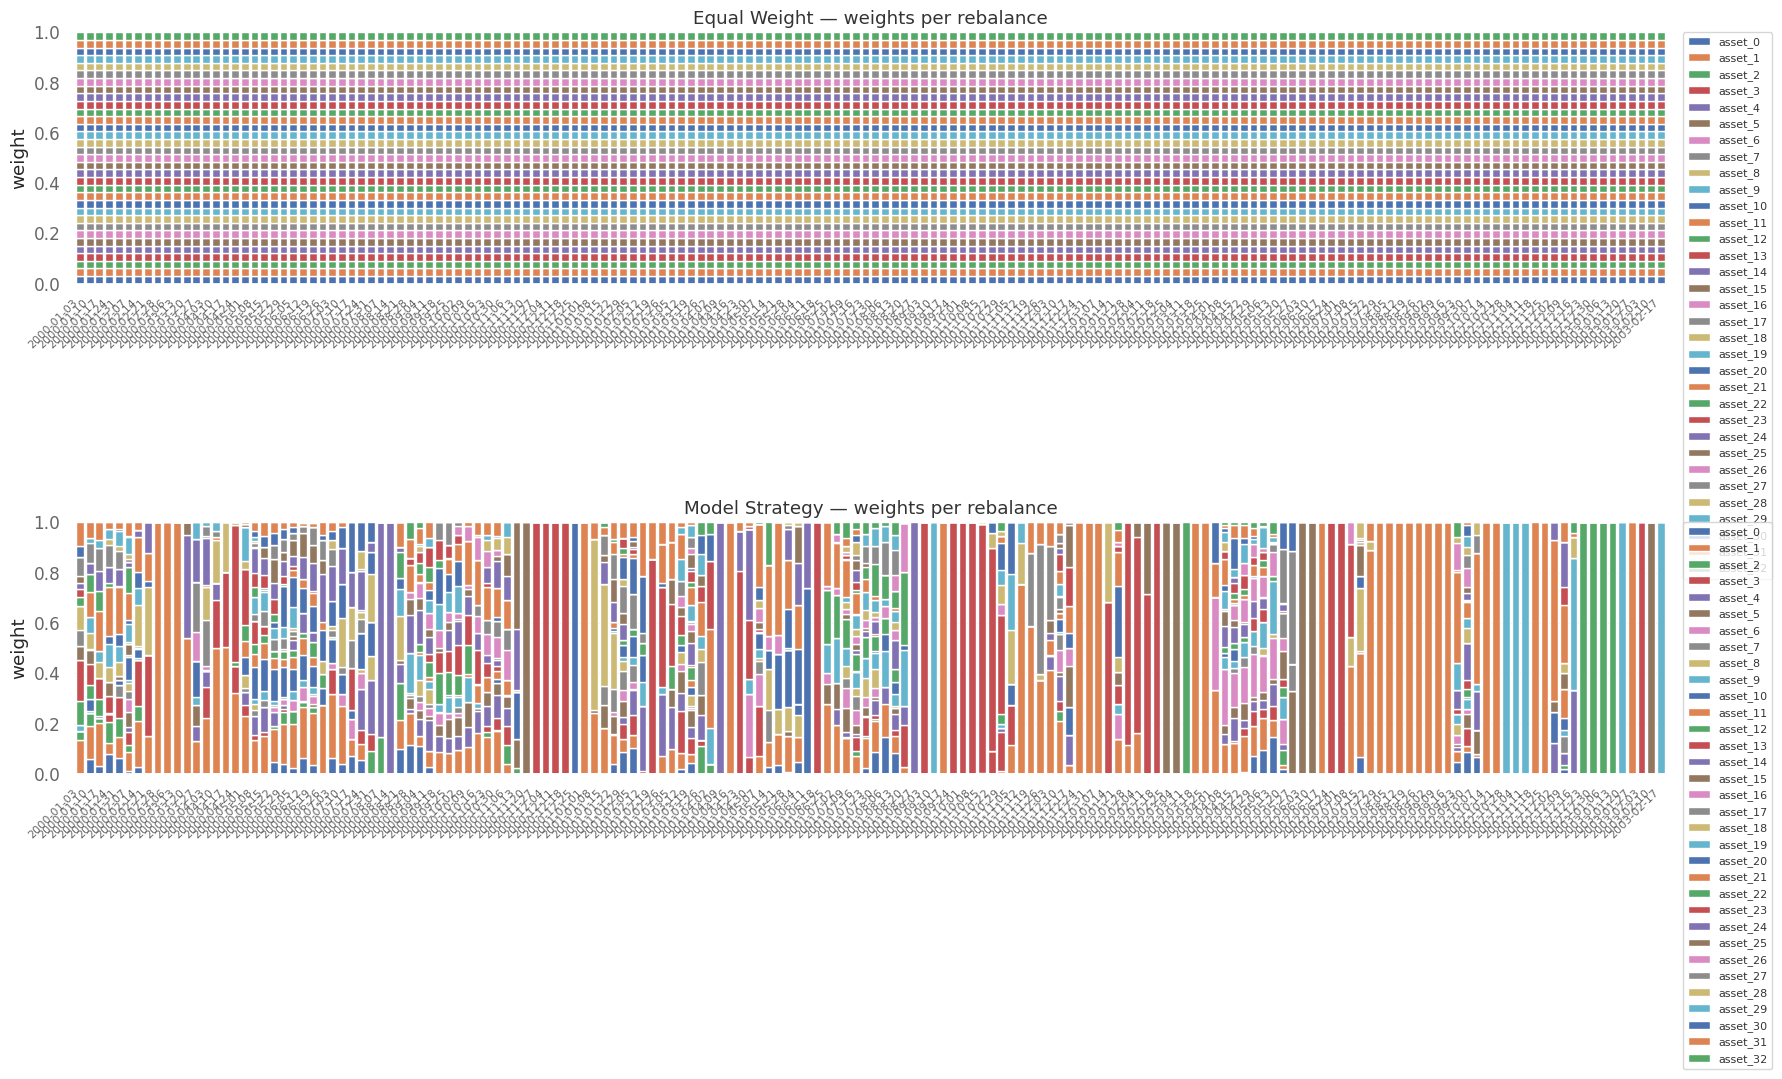

2026-07-25 03:03:14,443 - entities.portfolio - INFO - Strategy: Equal Weight vs Benchmark: Model Strategy


/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning:

invalid value encountered in divide

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning:

invalid value encountered in divide



ValueError: Cannot calculate a linear regression if all x values are identical

In [ ]:
# ==============================================================================
# ไฟล์: v4_4_0_portfolio_run.py (ฉบับสมบูรณ์ แก้ไข Error วันที่ซ้ำ/Regression)
# ==============================================================================
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

# --- Imports จากโปรเจกต์ของคุณ ---
from config import InferenceConfig
from utils import setup_logging, setup_random_seed
from entities import Portfolio

logger = setup_logging()
logger.info("✓ Imports OK")

# ── 1. Config ────────────────────────────────────────────────────────
cfg = InferenceConfig(
    name             = "portfolio_config",
    group            = "set_index",
    subgroup         = "set_idx50",
    experiment_name  = "v1_trial01_w20a33_ddpm_warmup-cosine_optuna",
    checkpoint_file  = "best_model.pt",
    num_simulations  = 1000,
    random_seed      = 72,
)
cfg = cfg.apply_experiment_config()

SPLIT = "test" # เปลี่ยนเป็น 'test' ได้ตามต้องการ
sim_dir = cfg.experiment_dir / "simulations" / f"{SPLIT}_all_n{cfg.num_simulations}"

setup_random_seed(cfg.random_seed)

print("=" * 60)
print("  V4-4-0 PORTFOLIO PIPELINE")
print("=" * 60)

# ── 2. Load Simulation Data ──────────────────────────────────────────
npz_path = sim_dir / "result_all_windows.npz"
if not npz_path.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ {npz_path} กรุณารัน Inferencing ก่อน")

data = np.load(npz_path, allow_pickle=True)

all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]
CLOSE_IDX = 0

print(f"  ✓ Loaded data from {SPLIT}_all_n{cfg.num_simulations}")

# ── 3. Prepare & Clean Data (แก้ปัญหา Index ซ้ำ/เรียงผิด) ──────────────
# 3.1 ยุบรวมแกน (Flatten)
gt_returns = all_log_ret_real[..., CLOSE_IDX].reshape(-1, A)  # (T*W, A)
gt_prices  = all_prices_real.reshape(-1, A)                   # (T*W, A)

mc_returns = all_log_ret_gen[..., CLOSE_IDX]                  # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3).reshape(N, -1, A) # (N, T*W, A)

# 3.2 สร้างและคลีน Datetime Index
if all_dates.ndim == 2 and all_dates.shape[1] == W:
    flat_dates = pd.to_datetime(all_dates.flatten())
else:
    all_dates_flat = []
    for i in range(T):
        date_val = all_dates[i] if np.isscalar(all_dates[i]) else all_dates[i, -1]
        dates_w = pd.bdate_range(end=pd.Timestamp(date_val), periods=W)
        all_dates_flat.append(dates_w)
    flat_dates = pd.DatetimeIndex(np.concatenate(all_dates_flat))

# หา Index ที่ "ไม่ซ้ำ" (Deduplicate)
unique_mask = ~flat_dates.duplicated(keep='last')
clean_dates = flat_dates[unique_mask]

# เรียงลำดับวันที่ให้ถูกต้อง (Sort)
sort_idx = np.argsort(clean_dates)
final_dates = clean_dates[sort_idx]

# 3.3 Apply การ Clean เข้ากับข้อมูลทั้งหมด
df_gt_returns = pd.DataFrame(gt_returns[unique_mask][sort_idx], index=final_dates, columns=tickers)
df_gt_prices  = pd.DataFrame(gt_prices[unique_mask][sort_idx], index=final_dates, columns=tickers)
mc_returns_clean = mc_returns[:, unique_mask, :][:, sort_idx, :]

print(f"  ✓ Cleaned Dates: {len(flat_dates)} -> {len(final_dates)} unique valid days")

# ── 4. Run Portfolio & Benchmark Comparison ─────────────────────────
pf = Portfolio(annual_risk_free_rate=0.02, trading_days=252)

strategies = {
    "Equal Weight": None,
    "Model Strategy": mc_returns_clean
}

reports_dir = cfg.experiment_dir / "simulations" / "portfolio" / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

print("\n🚀 Running Portfolio Optimization...")
results = pf.experiment(
    gt_returns=df_gt_returns,
    gt_prices=df_gt_prices,
    strategies=strategies,
    benchmark_strategy="Model Strategy",
    rebalance_freq=5,
    optimize_window=20,
    start_date=None,
    end_date=None,
    transaction_cost=0.001,
    init_cash=1.0,
    is_log_return=True,
    method="Per-Path",
    output_dir=reports_dir  # เซฟ Report ลงโฟลเดอร์แทนการปริ้นให้รกหน้าจอ
)

# แกะผลตอบแทนรายวันออกมา
final_returns = {}
for strat_name, strat_res in results.items():
    daily_ret = strat_res.returns.copy()
    daily_ret.index = final_dates[-len(daily_ret):]
    final_returns[strat_name] = daily_ret

# โหลด Benchmark จาก Yahoo Finance มาเทียบ
index_ticker = "^SET.BK"
print(f"\n📥 Loading Benchmark {index_ticker} from yfinance...")
fetch_start = final_dates[0] - pd.Timedelta(days=5)
fetch_end   = final_dates[-1] + pd.Timedelta(days=5)
index_data = yf.download(index_ticker, start=fetch_start, end=fetch_end, progress=False)

if not index_data.empty:
    if isinstance(index_data['Close'], pd.DataFrame):
        index_prices = index_data['Close'].iloc[:, 0]
    else:
        index_prices = index_data['Close'].squeeze()

    index_returns = index_prices.pct_change().dropna()
    final_returns[f"Market Index ({index_ticker})"] = index_returns.reindex(final_dates).fillna(0.0)
    print("  ✓ Benchmark loaded!")
else:
    print("  ❌ Failed to load Benchmark")

# ── 5. Plot Equity Curve สรุปผล ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
print("\n" + "═" * 70)
for strat_name, daily_ret in final_returns.items():
    eq = (1 + daily_ret).cumprod()
    tot = (eq.iloc[-1] - 1) * 100

    if "Market Index" in strat_name:
        ax.plot(eq.index, eq.values, label=f"{strat_name} (Total: {tot:.2f}%)", lw=2, color='black', ls='--')
    else:
        ax.plot(eq.index, eq.values, label=f"{strat_name} (Total: {tot:.2f}%)", lw=1.5, alpha=0.85)
    print(f"  {strat_name:<30} | Total Return: {tot:>8.2f}%")
print("═" * 70)

ax.set_title("Overall Portfolio Equity Curve vs Market Index", fontsize=13, fontweight='bold')
ax.set_ylabel("Portfolio Value (Base 1.0)")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")

# บันทึกรูป
plt.savefig(str(reports_dir / "overall_equity_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 1. รวมผลลัพธ์จากโมเดลของคุณ ──────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# สมมติว่าผลลัพธ์ของคุณเก็บอยู่ใน all_results
strategy_names = list(next(iter(all_results.values())).keys())
concat_returns: dict[str, pd.Series] = {}

for name in strategy_names:
    # ดึง daily return ของแต่ละ window มาต่อกัน
    parts = [res[name].returns for res in all_results.values()]
    merged = pd.concat(parts)
    merged = merged[~merged.index.duplicated(keep='last')].sort_index()
    concat_returns[name] = merged

# ── 2. โหลด Benchmark Index เข้ามาแจม ──────────────────────────────────
index_ticker = "^SET.BK"  # <-- แก้ชื่อ Ticker ตรงนี้ได้เลย (SET50 ใน yf อาจจะไม่มีข้อมูล)
print(f"📥 กำลังโหลด Index: {index_ticker} มาเป็น Benchmark เทียบ ...")

# ดึงข้อมูลให้ครอบคลุมช่วงเวลา (เผื่อวันหยุดหน้าหลัง)
datetime_index = concat_returns[strategy_names[0]].index
fetch_start = datetime_index[0] - pd.Timedelta(days=5)
fetch_end   = datetime_index[-1] + pd.Timedelta(days=5)

index_data = yf.download(index_ticker, start=fetch_start, end=fetch_end, progress=False)

if not index_data.empty:
    index_prices = index_data['Close'].squeeze()
    index_returns = index_prices.pct_change().dropna()
    aligned_index_returns = index_returns.reindex(datetime_index).fillna(0.0)

    # ยัดใส่ concat_returns ให้เป็น strategy หนึ่งไปเลย
    concat_returns[f"Market Index ({index_ticker})"] = aligned_index_returns
    print(f"  ✓ เพิ่ม {index_ticker} สำเร็จ!")
else:
    print(f"  ❌ ไม่พบข้อมูล {index_ticker} ข้ามการสร้าง Benchmark")

# ── 3. พล็อตกราฟเปรียบเทียบ (Equity Curve) ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

print("\n" + "═" * 70)
print("  Portfolio Stats Summary (Including Market Index)")
print("═" * 70)

for strat_name, daily_ret in concat_returns.items():
    equity_curve = (1 + daily_ret).cumprod()
    total_return_pct = (equity_curve.iloc[-1] - 1) * 100

    # ทำให้เส้น Index ตลาดเป็นเส้นประสีดำจะได้ดูง่าย
    if "Market Index" in strat_name:
        ax.plot(equity_curve.index, equity_curve.values,
                label=f"{strat_name} (Total: {total_return_pct:.2f}%)",
                linewidth=2, color='black', linestyle='--')
    else:
        ax.plot(equity_curve.index, equity_curve.values,
                label=f"{strat_name} (Total: {total_return_pct:.2f}%)",
                linewidth=1.5, alpha=0.85)

    print(f"  {strat_name:<30} | Total Return: {total_return_pct:>8.2f}% | Length: {len(daily_ret)} days")

print("═" * 70)

ax.set_title("Overall Portfolio Equity Curve", fontsize=13, fontweight='bold')
ax.set_ylabel("Portfolio Value (Base 1.0)")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
plt.show()

# 4. Results Summary

In [ ]:
print(f"{'strategy':<14} {'sim_win':>8} {'rebal_win':>10} {'init':>8} {'final':>8} {'P&L':>8} {'ret%':>8}")
print("─" * 70)

for win_idx, results_w in all_results.items():
    for name, result in results_w.items():
        for j, wpf in enumerate(result.window_portfolios):
            final   = float(wpf.final_value())
            pnl     = float(wpf.total_profit())
            ret_pct = (final / INIT_CASH - 1) * 100
            print(f"{name:<14} {win_idx:>8} {j+1:>10} {INIT_CASH:>8.2f} {final:>8.4f} {pnl:>8.4f} {ret_pct:>7.2f}%")

strategy        sim_win  rebal_win     init    final      P&L     ret%
──────────────────────────────────────────────────────────────────────


NameError: name 'all_results' is not defined

# 5. Equity Curve & Stats

In [ ]:
# ── 1. Concat returns ราย strategy ข้าม sim-windows ──────────────────
strategy_names = list(next(iter(all_results.values())).keys())

concat_returns: dict[str, pd.Series] = {}
for name in strategy_names:
    parts = []
    for win_idx in sorted(all_results.keys()):
        parts.append(all_results[win_idx][name].returns)
    concat_returns[name] = pd.concat(parts)

# ── 2. Compute stats ─────────────────────────────────────────────────
def compute_stats(ret: pd.Series, rf: float) -> dict:
    cum       = (1 + ret).cumprod()
    total_ret = cum.iloc[-1] - 1
    ann_ret   = qs.stats.cagr(ret, rf=rf)
    sharpe    = qs.stats.sharpe(ret, rf=rf)
    sortino   = qs.stats.sortino(ret, rf=rf)
    max_dd    = qs.stats.max_drawdown(ret)
    calmar    = qs.stats.calmar(ret)

    dd = qs.stats.to_drawdown_series(ret)
    in_dd = dd < 0
    max_consec = 0
    curr = 0
    for v in in_dd:
        curr = curr + 1 if v else 0
        max_consec = max(max_consec, curr)

    return {
        "Cum. Ret. (%)": f"{total_ret*100:.2f}%",
        "Ann. Ret. (%)": f"{ann_ret*100:.2f}%",
        "Sharpe":        f"{sharpe:.3f}",
        "Sortino":       f"{sortino:.3f}",
        "Calmar":        f"{calmar:.3f}",
        "Max DD (%)":    f"{max_dd*100:.2f}%",
        "LDD (days)":    f"{max_consec}",
    }

rf        = portfolio.daily_risk_free_rate
stats_all = {name: compute_stats(concat_returns[name], rf) for name in strategy_names}

# ── 3. Plot ──────────────────────────────────────────────────────────
colors = {"model": "#0066FF"}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.35)

# --- Equity curve ---
ax_eq = fig.add_subplot(gs[0])
for name, ret in concat_returns.items():
    cum = (1 + ret).cumprod()
    ax_eq.plot(cum.index, cum.values, label=name, color=colors.get(name, None), linewidth=1.5)

# sim-window boundaries
window_dates = []
for win_idx in sorted(all_results.keys()):
    ret = next(iter(all_results[win_idx].values())).returns
    window_dates.append(ret.index[0])
for d in window_dates[1:]:
    ax_eq.axvline(d, color="gray", linewidth=0.6, linestyle="--", alpha=0.5)

ax_eq.set_title("Cumulative Returns — all sim-windows", fontsize=13)
ax_eq.set_ylabel("Growth of 1.0")
ax_eq.legend()
ax_eq.grid(alpha=0.3)

# --- Drawdown ---
ax_dd = fig.add_subplot(gs[1])
for name, ret in concat_returns.items():
    dd = qs.stats.to_drawdown_series(ret)
    ax_dd.fill_between(dd.index, dd.values, 0, alpha=0.4, label=name, color=colors.get(name, None))
ax_dd.set_title("Drawdown", fontsize=11)
ax_dd.set_ylabel("DD")
ax_dd.legend(fontsize=8)
ax_dd.grid(alpha=0.3)

# --- Daily returns ---
ax_ret = fig.add_subplot(gs[2])
for name, ret in concat_returns.items():
    ax_ret.plot(ret.index, ret.values, alpha=0.6, linewidth=0.7,
                label=name, color=colors.get(name, None))
ax_ret.axhline(0, color="black", linewidth=0.5)
ax_ret.set_title("Daily Returns", fontsize=11)
ax_ret.set_ylabel("Return")
ax_ret.legend(fontsize=8)
ax_ret.grid(alpha=0.3)

report_dir = cfg.experiment_dir / "simulations" / "portfolio" / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(str(report_dir / "equity_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Stats table ───────────────────────────────────────────────────
stats_df = pd.DataFrame(stats_all).T
stats_df.index.name = "Strategy"
print("\n" + "═" * 60)
print("  Portfolio Stats (full period — all sim-windows concat)")
print("═" * 60)
print(stats_df.to_string())
print("═" * 60)